
# 🐣 Human-Embryo *Phase Classifier* — End-to-End Notebook  

This notebook trains a deep network that maps a **single time-lapse frame**  
to its *morphokinetic phase* (`t2`, `t3`, …, `tB`).

## Paths

```python
PROJECT_ROOT            = Path("..")
ANNOT_DIR               = PROJECT_ROOT / 'data' / 'embryo_dataset_annotations'
```


In [34]:

# @title 🔧 Install & Imports

import random, re, math, json, os, gc
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.v2 as v2
import torchvision.models as models

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


In [35]:
# @title 📁 Paths & Device
PROJECT_ROOT        = Path("..").resolve()
FOCAL_PLANES        = ['F0', 'F-15', 'F-30', 'F-45', 'F15', 'F30', 'F45']
DATA_ROOTS          = {fp: PROJECT_ROOT / 'data' / 'embryo_dataset_silver' / fp for fp in FOCAL_PLANES}
ANNOT_DIR           = PROJECT_ROOT / 'data' / 'embryo_dataset_annotations'

# Verify all focal plane directories exist
for fp, dr in DATA_ROOTS.items():
    assert dr.is_dir(), f"{dr} not found"
assert ANNOT_DIR.is_dir(), f"{ANNOT_DIR} not found"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)
print(f"Focal planes: {FOCAL_PLANES}")


Running on cuda
Focal planes: ['F0', 'F-15', 'F-30', 'F-45', 'F15', 'F30', 'F45']


In [36]:
# @title 🚫 Embryo Exclusion List
EXCLUDE_EMBRYOS = {
    "BJ492-8",
    "ALR493-6"
}

In [37]:
# @title ⚙️ Helpers

PHASES = [
    "tPB2", "tPNa", "tPNf",
    "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+",
    "tM", "tSB", "tB", "tEB", "tHB"
]
PHASE2IDX = {p: i for i, p in enumerate(PHASES)}
IDX2PHASE = {i: p for p, i in PHASE2IDX.items()}
NUM_CLASSES = len(PHASES)

def extract_frame_idx(name: str):
    m = re.search(r"(\d+)\.jpeg$", name)
    return int(m.group(1)) if m else None

def index_frames(folder: Path):
    mapping = {}
    for fp in folder.glob("*.jpeg"):
        m = re.search(r"(\d+)\.jpeg$", fp.name)
        if m:
            mapping[int(m.group(1))] = fp
    return mapping

In [38]:
# @title 🗄️ PhaseDataset (filters empty frames)

FRAMES_PER_PHASE = 7      # None → keep all

class PhaseDataset(Dataset):
    def __init__(self, embryo_ids, transform, focal_planes=None, frames_per_phase=10):
        self.transform = transform
        self.focal_planes = focal_planes or list(DATA_ROOTS.keys())
        self.samples   = []           # [(img_path, label_idx), …]

        for eid in tqdm(embryo_ids):
            csv_path = ANNOT_DIR / f"{eid}_phases.csv"
            if not csv_path.is_file():      # skip missing
                print(f"Warning: missing annotation for {eid}, skipping")
                continue

            df = pd.read_csv(csv_path, header=None,
                             names=["phase", "start", "end"])

            # Process each focal plane for this embryo
            for fp in self.focal_planes:
                data_root = DATA_ROOTS[fp]
                frame2path = index_frames(data_root / eid)

                for phase, start, end in df.itertuples(index=False):
                    phase = str(phase).strip()
                    if phase not in PHASE2IDX:          # unknown label → skip
                        continue

                    # ---- subsample frames ----------------------------------
                    if frames_per_phase and (end - start + 1) > frames_per_phase:
                        sel = np.linspace(start, end, frames_per_phase, dtype=int)
                    else:
                        sel = range(start, end + 1)

                    paths = [frame2path.get(f) for f in sel if frame2path.get(f)]

                    lbl = PHASE2IDX[phase]
                    for p in paths:
                        self.samples.append((p, lbl))

        print(f"Got {len(self.samples):,} frames from {len(self.focal_planes)} focal planes")
        self.num_classes = NUM_CLASSES

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert("L")
        return self.transform(img), torch.tensor(label)


In [39]:

# @title 🧰 Transforms & Data Split
MAX_EMBRYOS = None          # 25 for a quick run

IMG_SIZE = 256
# Common transforms for all sets (resize + normalize)
base_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),  # normalize all sets consistently
])

# Additional augmentations only for training
train_aug = v2.Compose([
    # Microscopy-specific augmentations
    v2.ColorJitter(
        brightness=0.6,  # wider brightness range
        contrast=0.6,    # wider contrast range
    ),
    # Enhance local features
    v2.RandomApply([
        v2.RandomAdjustSharpness(sharpness_factor=1.5)
    ], p=0.3),
    # Simulate focus variations
    v2.RandomApply([
        v2.GaussianBlur(kernel_size=(3,3), sigma=(0.1, 1.0))
    ], p=0.3),
    # Mild geometric transformations (embryos don't rotate much in real life)
    v2.RandomAffine(
        degrees=180,             # Limited rotation
        translate=(0.05, 0.05), # Small translations
        scale=(0.85, 1.15),     # Minor scale changes
        shear=(-5, 5)           # Subtle shear
    ),
    # Custom augmentation for microscopy artifacts
    v2.RandomApply([
        v2.GaussianBlur(kernel_size=(5,5), sigma=(0.1, 0.5)),  # Simulate slight defocus
        v2.RandomAdjustSharpness(sharpness_factor=0.8)         # Simulate slight blur
    ], p=0.2),
])

# Training pipeline: base transforms -> augmentations -> normalize
train_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    train_aug,
    T.Normalize([0.5], [0.5])
])

# Val/Test pipeline: just the base transforms including normalization
val_tfm = base_tfm

In [40]:
# embryo-level split
all_embryos = sorted([p.name for p in DATA_ROOTS[FOCAL_PLANES[0]].iterdir() if p.is_dir()
                      and p.name not in EXCLUDE_EMBRYOS])

random.seed(42)
np.random.seed(42)
random.shuffle(all_embryos)

# respect MAX_EMBRYOS
if MAX_EMBRYOS is not None:
    assert MAX_EMBRYOS >= 3, "Need ≥3 embryos to form train/val/test"
    all_embryos = all_embryos[:MAX_EMBRYOS]

n_val = max(1, int(0.10*len(all_embryos)))
n_test = max(1, int(0.10*len(all_embryos)))
val_embryos = all_embryos[:n_val]
test_embryos = all_embryos[n_val:n_val+n_test]
train_embryos = all_embryos[n_val+n_test:]

# ✅ Ensure class-wise coverage in VAL/TEST by pulling missing-phase embryos from TRAIN
import pandas as pd

# Cache: embryo -> set(phases present in its CSV)
def load_embryo_phases(eid: str):
    csv_path = ANNOT_DIR / f"{eid}_phases.csv"
    if not csv_path.is_file():
        return set()
    df = pd.read_csv(csv_path, header=None, names=["phase", "start", "end"])
    return {
        str(p).strip()
        for p in df["phase"].tolist()
        if str(p).strip() in PHASE2IDX
    }

embryo2phases = {eid: load_embryo_phases(eid) for eid in all_embryos}

def split_phase_coverage(eids):
    covered = set()
    for eid in eids:
        covered |= embryo2phases.get(eid, set())
    return covered

def enforce_coverage_for(split_name, split_list, train_list):
    added = []
    covered = split_phase_coverage(split_list)
    for phase in PHASES:
        if phase not in covered:
            # find a donor embryo in TRAIN that has this phase
            donor = next((eid for eid in train_list
                          if phase in embryo2phases.get(eid, set())
                          and eid not in split_list), None)
            if donor is not None:
                train_list.remove(donor)
                split_list.append(donor)
                added.append((phase, donor))
                covered |= embryo2phases.get(donor, set())
            else:
                print(f"[warn] No available TRAIN embryo with phase '{phase}' to add to {split_name}.")
    if added:
        print(f"[info] Added to {split_name}: " + ", ".join([f"{ph}->{eid}" for ph, eid in added]))
    else:
        print(f"[info] {split_name} already covers all phases.")

# Apply to VAL then TEST (only pull from TRAIN)
enforce_coverage_for("VAL",  val_embryos,  train_embryos)
enforce_coverage_for("TEST", test_embryos, train_embryos)

# (Optional) quick sanity check
for name, split in [("TRAIN", train_embryos), ("VAL", val_embryos), ("TEST", test_embryos)]:
    cov = split_phase_coverage(split)
    missing = [p for p in PHASES if p not in cov]
    print(f"{name}: {len(split)} embryos | missing phases: {missing if missing else 'None'}")


print(f"Embryos ➜ train {len(train_embryos)} | val {len(val_embryos)} | test {len(test_embryos)}")


[info] Added to VAL: tHB->LS123-3
[info] TEST already covers all phases.
TRAIN: 561 embryos | missing phases: None
VAL: 71 embryos | missing phases: None
TEST: 70 embryos | missing phases: None
Embryos ➜ train 561 | val 71 | test 70


In [41]:
train_ds = PhaseDataset(train_embryos, transform=train_tfm, frames_per_phase=FRAMES_PER_PHASE)
val_ds   = PhaseDataset(val_embryos,   transform=val_tfm, frames_per_phase=FRAMES_PER_PHASE)
test_ds  = PhaseDataset(test_embryos,  transform=val_tfm, frames_per_phase=FRAMES_PER_PHASE)

from collections import Counter
train_labels = [lbl for _, lbl in train_ds.samples]
class_counts = Counter(train_labels)
num_classes  = train_ds.num_classes

# Weighted sampler for TRAIN to help rare phases
import numpy as np
from torch.utils.data import DataLoader, WeightedRandomSampler

sample_w = np.array([1.0 / class_counts[l] for _, l in train_ds.samples], dtype=np.float64)
sampler  = WeightedRandomSampler(torch.from_numpy(sample_w), num_samples=len(sample_w), replacement=True)

BATCH = 32
train_dl = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=8, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=8, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=8, pin_memory=True)

  0%|          | 0/561 [00:00<?, ?it/s]

Got 289,387 frames from 7 focal planes


  0%|          | 0/71 [00:00<?, ?it/s]

Got 37,282 frames from 7 focal planes


  0%|          | 0/70 [00:00<?, ?it/s]

Got 36,630 frames from 7 focal planes


,Phase,Train,Val,Test
0,tPB2,23282,2947,2940
1,tPNa,25043,3136,3283
2,tPNf,26543,3262,3261
3,t2,26374,3359,3395
4,t3,11109,1435,1078
5,t4,23890,3080,3282
6,t5,13931,1988,1839
7,t6,15866,2247,2030
8,t7,15701,1997,1932
9,t8,22107,2533,2919


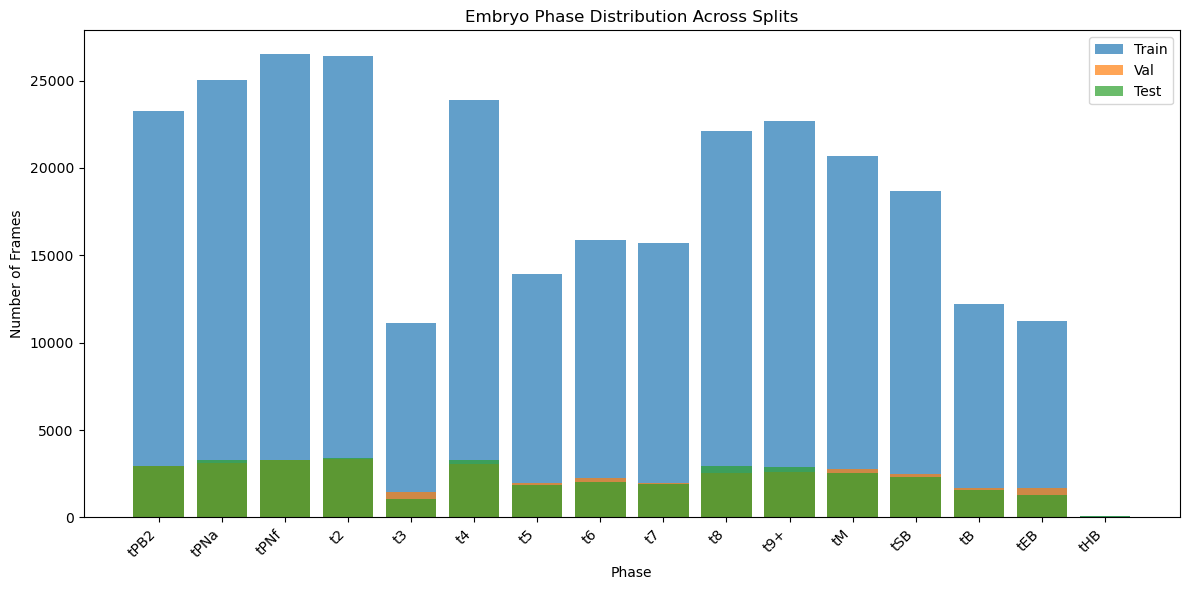

In [42]:
# 🧮 Class Distribution Visualization
from collections import Counter
import matplotlib.pyplot as plt

# Count samples per class
train_counts = Counter([lbl for _, lbl in train_ds.samples])
val_counts = Counter([lbl for _, lbl in val_ds.samples])
test_counts = Counter([lbl for _, lbl in test_ds.samples])

# Create a DataFrame for visualization
phase_names = [IDX2PHASE[i] for i in range(NUM_CLASSES)]
df_counts = pd.DataFrame({
    'Phase': phase_names,
    'Train': [train_counts.get(i, 0) for i in range(NUM_CLASSES)],
    'Val': [val_counts.get(i, 0) for i in range(NUM_CLASSES)],
    'Test': [test_counts.get(i, 0) for i in range(NUM_CLASSES)]
})

display(df_counts)

# Plot distributions
plt.figure(figsize=(12, 6))
plt.bar(df_counts['Phase'], df_counts['Train'], label='Train', alpha=0.7)
plt.bar(df_counts['Phase'], df_counts['Val'], label='Val', alpha=0.7)
plt.bar(df_counts['Phase'], df_counts['Test'], label='Test', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Phase')
plt.ylabel('Number of Frames')
plt.title('Embryo Phase Distribution Across Splits')
plt.legend()
plt.tight_layout()
plt.show()


In [43]:
# 🧾 Embryo IDs per class (per split and overall)

from collections import defaultdict

def collect_embryo_ids_per_class(dataset):
    phase_to_ids = defaultdict(set)  # {label_idx: set(embryo_ids)}
    for path, lbl in dataset.samples:
        eid = path.parent.name  # folder name is the embryo id
        phase_to_ids[lbl].add(eid)
    return phase_to_ids

train_ids = collect_embryo_ids_per_class(train_ds)
val_ids   = collect_embryo_ids_per_class(val_ds)
test_ids  = collect_embryo_ids_per_class(test_ds)

# Build "overall" as the union across splits
overall_ids = defaultdict(set)
for i in range(NUM_CLASSES):
    overall_ids[i] = set().union(train_ids.get(i, set()),
                                 val_ids.get(i, set()),
                                 test_ids.get(i, set()))

def print_ids(title, mapping):
    print(f"\n=== {title} ===")
    for i, phase in enumerate(PHASES):
        ids = sorted(mapping.get(i, set()))
        print(f"{phase} [{len(ids)} embryos]: {', '.join(ids) if ids else '-'}")

#print_ids("TRAIN embryo IDs per class", train_ids)
#print_ids("VAL embryo IDs per class",   val_ids)
#print_ids("TEST embryo IDs per class",  test_ids)
#print_ids("OVERALL embryo IDs per class (union)", overall_ids)


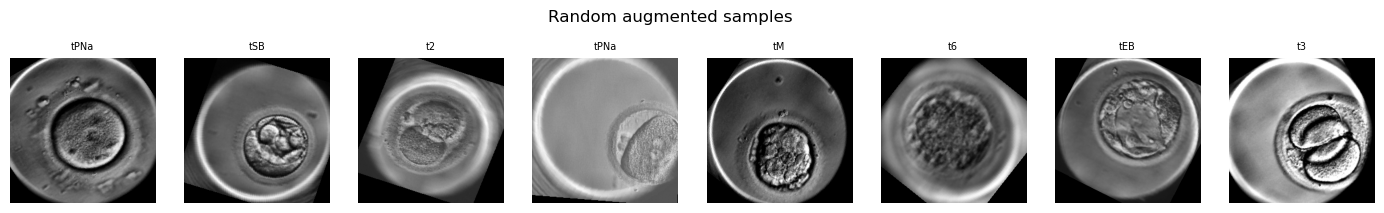

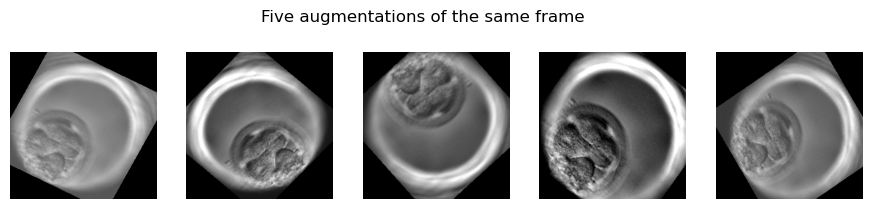

In [44]:
# @title 🔍 Preview data‐augmentations
import random, matplotlib.pyplot as plt
import torch

# -----------------------------------------------
# helper to de-normalise a 1×H×W tensor
def denorm(x):
    return (x*0.5 + 0.5).clamp(0,1).squeeze().cpu().numpy()

# 1)  Eight random augmented frames ----------------
N = 8
idxs = random.sample(range(len(train_ds)), N)
fig, axes = plt.subplots(1, N, figsize=(2.2*N, 2.5))

for ax, i in zip(axes, idxs):
    img, lbl = train_ds[i]
    ax.imshow(denorm(img), cmap='gray')
    ax.set_title(IDX2PHASE[lbl.item()], fontsize=7)
    ax.axis('off')
fig.suptitle("Random augmented samples", fontsize=12)
plt.show()

# 2)  Same frame, 5 different augmentations --------
idx = random.choice(range(len(train_ds)))
base_path, _ = train_ds.samples[idx]
base_img = Image.open(base_path).convert("L")

fig, axes = plt.subplots(1, 5, figsize=(11, 2.4))
for ax in axes:
    aug = train_tfm(base_img)
    ax.imshow(denorm(aug), cmap='gray')
    ax.axis('off')
fig.suptitle("Five augmentations of the same frame", fontsize=12)
plt.show()


In [45]:

# @title 🧠 Model
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights


n_classes = train_ds.num_classes
model = efficientnet_v2_s(weights=None)

# Convert first layer to grayscale while preserving pre-trained weights
old_conv = model.features[0][0]
new_conv = nn.Conv2d(1, old_conv.out_channels, kernel_size=3, stride=2, padding=1, bias=False)
# Average the RGB weights to create grayscale weights
with torch.no_grad():
    new_conv.weight.data = old_conv.weight.data.sum(dim=1, keepdim=True) / 3.0

model.features[0][0] = new_conv

# Enhanced classifier with batch norm and more capacity
in_feats = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_feats, n_classes)
)

model.to(device)

# Two-phase training setup
optimizer = torch.optim.AdamW(model.parameters(), lr = 3e-3, weight_decay=1e-4)

from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(
    optimizer, mode="min", factor=0.8, patience=2, min_lr=1e-7, verbose=True
)

# Loss with label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5080 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5080 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(
/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [46]:
MIXUP_ALPHA, MIXUP_PROB = 0.6, 0.6
def apply_mixup(x, y, alpha=MIXUP_ALPHA):
    if alpha <= 0 or x.size(0) < 2: return x, (y, None, 1.0)
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], (y, y[idx], lam)

In [47]:
EPOCHS = 1000
PATIENCE = 10  # Early stopping patience

best_loss = float('inf')
best_state = None
epochs_no_improve = 0
loss_history = []

for epoch in range(1, EPOCHS+1):  
    # --- train ---
    model.train()
    tr_loss = 0.0
    tr_hits = 0
    for xb, yb in tqdm(train_dl, desc=f"Epoch {epoch}/{EPOCHS}"):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        if np.random.rand() < MIXUP_PROB:
            xb, (y1, y2, lam) = apply_mixup(xb, yb)
            logits = model(xb)
            loss = lam*criterion(logits, y1) + (1-lam)*criterion(logits, y2)
        else:
            logits = model(xb)
            loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * xb.size(0)
        tr_hits += (logits.argmax(1) == yb).sum().item()
    tr_loss /= len(train_ds)
    tr_acc = tr_hits / len(train_ds)

    # --- val ---
    model.eval()
    val_loss = 0.0
    val_hits = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            val_hits += (logits.argmax(1) == yb).sum().item()
    val_loss /= len(val_ds)
    val_acc = val_hits / len(val_ds)

    # Step scheduler after each batch in train loop
    scheduler.step(val_loss)
    curr_lr = optimizer.param_groups[0]['lr']
    print(f"[{epoch:02d}] train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f} | lr {curr_lr:.2e}")
    loss_history.append((tr_loss, val_loss))

    # --- early stop on val loss ---
    if val_loss < best_loss - 1e-6:
        best_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"\t*** New best! Val Loss: {val_loss:.4f} ***")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping after {epochs_no_improve} epochs.")
            break

# load best
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

Epoch 1/1000:   0%|          | 0/9044 [00:00<?, ?it/s]

[01] train loss 2.7250 acc 0.081 | val loss 2.2550 acc 0.218 | lr 3.00e-03
	*** New best! Val Loss: 2.2550 ***


Epoch 2/1000:   0%|          | 0/9044 [00:00<?, ?it/s]

[02] train loss 2.2026 acc 0.249 | val loss 1.9183 acc 0.381 | lr 3.00e-03
	*** New best! Val Loss: 1.9183 ***


Epoch 3/1000:   0%|          | 0/9044 [00:00<?, ?it/s]

...

[29] train loss 1.5267 acc 0.490 | val loss 1.4834 acc 0.600 | lr 1.23e-03


Epoch 30/1000:   0%|          | 0/9044 [00:00<?, ?it/s]

[30] train loss 1.5241 acc 0.491 | val loss 1.4999 acc 0.598 | lr 9.83e-04


Epoch 31/1000:   0%|          | 0/9044 [00:00<?, ?it/s]

[31] train loss 1.5014 acc 0.501 | val loss 1.5044 acc 0.590 | lr 9.83e-04

Early stopping after 10 epochs.


Test inference:   0%|          | 0/164 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        tPB2      0.731     0.840     0.782       420
        tPNa      0.835     0.725     0.776       469
        tPNf      0.652     0.839     0.734       466
          t2      0.820     0.810     0.815       485
          t3      0.437     0.610     0.509       154
          t4      0.742     0.615     0.673       468
          t5      0.412     0.436     0.424       264
          t6      0.415     0.362     0.387       290
          t7      0.332     0.312     0.322       279
          t8      0.622     0.560     0.590       423
         t9+      0.698     0.620     0.656       410
          tM      0.638     0.743     0.687       366
         tSB      0.662     0.650     0.655       331
          tB      0.553     0.561     0.557       223
         tEB      0.673     0.572     0.618       187
         tHB      1.000     0.077     0.143        13

    accuracy                          0.643      5248
   macro avg      0.639   

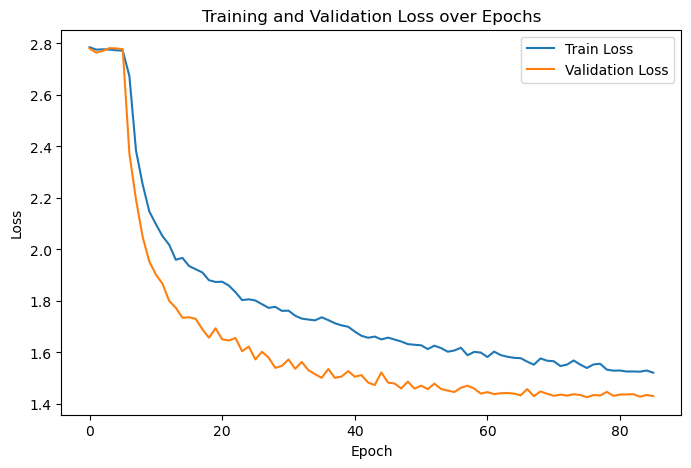

In [ ]:
# @title 📊 Test‑Set Report
model.eval()
preds, trues = [], []
with torch.no_grad():
    for x, y in tqdm(test_dl, desc="Test inference"):
        logits = model(x.to(device))
        preds.extend(logits.argmax(1).cpu().numpy())
        trues.extend(y.numpy())

# Get unique labels present in the test set
unique_labels = sorted(list(set(trues)))

# Filter and order target_names based on unique_labels
target_names = [IDX2PHASE[i] for i in sorted(set(trues))]


report = classification_report(trues, preds, labels=unique_labels, target_names=target_names, digits=3)
print(report)
cm = confusion_matrix(trues, preds, labels=unique_labels)
print("Confusion matrix\n", cm)

# loss history plot
train_losses, val_losses = zip(*loss_history)
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

In [ ]:

# @title 💾 Save Model
import datetime, torch
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = f"embryo_phase_models/phase_classifier_{timestamp}.pth"
torch.save(model, out_path)
print("Model saved to", out_path)


Model saved to embryo_phase_models/phase_classifier_20251104_013853.pth
